In [ ]:
import numpy as np
import joblib
import random
import time  # 🕒 시간 측정
from scipy.ndimage import rotate, shift, zoom

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline   # 🔹 ⭐ 중요: 이거 추가!

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

In [ ]:
# ==========================================
# 1. 사용자 정의 전처리 클래스
# ==========================================
class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target
        self.target_size = target_size
        self.final_size = final_size
        self.noise_threshold = noise_threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:
            side = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, side, side)

        processed = []
        for img in X:
            img = self.normalize_scale(img)
            img = self.remove_noise(img)
            img = self.normalize_stroke(img)
            img = self.normalize_size(img)
            img = self.center_align(img)
            processed.append(img)

        processed = np.array(processed)
        return processed.reshape(len(processed), -1)

    # --- 내부 메서드 ---
    def normalize_scale(self, img):
        img = img.astype(np.float32)
        if img.max() > 1: img = img / 255.0
        return img

    def remove_noise(self, img):
        img = img.copy()
        img[img < self.noise_threshold] = 0.0
        return img

    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        if mean_val == 0: return img
        scale_factor = self.stroke_target / mean_val
        img = img * scale_factor
        img = np.clip(img, 0, 1)
        return img

    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2 = coords[0].min(), coords[0].max()
        c1, c2 = coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h == 0 or w == 0: return np.zeros((self.final_size, self.final_size))
        zoom_h = self.target_size / h
        zoom_w = self.target_size / w
        digit_resized = zoom(digit, (zoom_h, zoom_w))
        return digit_resized

    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        if h > self.final_size or w > self.final_size:
            h_start = (h - self.final_size) // 2
            w_start = (w - self.final_size) // 2
            img = img[h_start:h_start+self.final_size, w_start:w_start+self.final_size]
            h, w = img.shape
        y0 = (self.final_size - h) // 2
        x0 = (self.final_size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
        return canvas

In [ ]:
# ==========================================
# 2. 데이터 증강 함수
# ==========================================
def apply_augment_single(img, mode, rotate_range=15, shift_range=2, zoom_range=0.1):
    if mode == 'rotate':
        angle = random.uniform(-rotate_range, rotate_range)
        img = rotate(img, angle, reshape=False, mode='constant', cval=0)
    elif mode == 'shift':
        dx = random.uniform(-shift_range, shift_range)
        dy = random.uniform(-shift_range, shift_range)
        img = shift(img, [dy, dx], mode='constant', cval=0)
    elif mode == 'zoom':
        factor = random.uniform(1.0, 1.0 + zoom_range)
        h, w = img.shape
        zoomed_img = zoom(img, factor, mode='constant', cval=0)
        zh, zw = zoomed_img.shape
        start_h = max((zh - h) // 2, 0)
        start_w = max((zw - w) // 2, 0)
        img = zoomed_img[start_h:start_h+h, start_w:start_w+w]
        if img.shape != (28, 28):
            img = img[:28, :28]
    return img

def custom_augment(X, y, multiplier=1):
    if multiplier <= 1:
        return X, y

    X = np.array(X)
    y = np.array(y)

    if X.ndim == 2:
        X_reshaped = X.reshape(-1, 28, 28)
    else:
        X_reshaped = X

    X_out = []
    y_out = []

    for img, label in zip(X_reshaped, y):
        X_out.append(img)
        y_out.append(label)
        for _ in range(multiplier - 1):
            mode = random.choice(['rotate', 'shift', 'zoom'])
            aug_img = apply_augment_single(img, mode)
            X_out.append(aug_img)
            y_out.append(label)

    X_out = np.array(X_out).reshape(len(X_out), -1)
    y_out = np.array(y_out)
    return X_out, y_out

In [ ]:
# ==========================================
# 3. 데이터 로드 및 전처리 (전처리 -> 분할 -> 증강)
# ==========================================
def load_preprocess_and_augment(hand_path, org_path, augment_factor=1):
    print(f"\n[Data Prep] Loading & Preprocessing... Augment Factor: {augment_factor}x")

    try:
        d_hand = np.load(hand_path, allow_pickle=True)
        X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)

        d_org = np.load(org_path, allow_pickle=True)
        X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    except Exception as e:
        print(f"Error loading files: {e}")
        return None, None, None, None

    # 전처리
    preprocessor = CustomImagePreprocess()
    print("  - Preprocessing Handmade data...")
    X_hand_processed = preprocessor.transform(X_hand)
    print("  - Preprocessing Original MNIST data...")
    X_org_processed = preprocessor.transform(X_org)

    # 분할
    X_hand_tr, X_hand_te, y_hand_tr, y_hand_te = train_test_split(
        X_hand_processed, y_hand, test_size=0.2, random_state=42, stratify=y_hand
    )
    X_org_tr, X_org_te, y_org_tr, y_org_te = train_test_split(
        X_org_processed, y_org, test_size=0.2, random_state=42, stratify=y_org
    )

    # 증강
    if augment_factor > 1:
        print(f"  - Augmenting Handmade Train ({len(X_hand_tr)} -> {augment_factor}x)...")
        X_hand_tr, y_hand_tr = custom_augment(X_hand_tr, y_hand_tr, multiplier=augment_factor)

    # 병합
    X_train = np.concatenate([X_hand_tr, X_org_tr])
    y_train = np.concatenate([y_hand_tr, y_org_tr])
    X_test = np.concatenate([X_hand_te, X_org_te])
    y_test = np.concatenate([y_hand_te, y_org_te])

    print(f"  - Final Train Size: {X_train.shape}, Test Size: {X_test.shape}")
    return X_train, X_test, y_train, y_test

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
import joblib
import time
import os

def run_experiment(scenario_name, X_train, X_test, y_train, y_test):
    os.environ["OMP_NUM_THREADS"] = "2"
    os.environ["MKL_NUM_THREADS"] = "2"

    print("\n" + "="*60)
    print(f"▶ Scenario: {scenario_name}")
    print("="*60)

    # 🔥 n_estimators는 Halving에서만 조절됨
    param_dist = {
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'subsample': [0.8, 1.0]
    }

    gb = GradientBoostingClassifier(random_state=42)

    print("  - Starting Halving Random Search (Fast Optimization)...")

    halving_search = HalvingRandomSearchCV(
        gb,
        param_distributions=param_dist,
        resource='n_estimators',
        min_resources=50,
        max_resources=200,
        factor=3,
        aggressive_elimination=True,
        cv=2,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    # 🔹 전체의 20%만 사용 (처음 튜닝용)
    X_small, _, y_small, _ = train_test_split(
        X_train, y_train, stratify=y_train, test_size=0.8, random_state=42
    )

    # ⏱ Training Time (Fit Time) 측정 시작
    start_time = time.time()
    halving_search.fit(X_small, y_small)
    end_time = time.time()

    training_time = end_time - start_time # Fit Time

    best_model = halving_search.best_estimator_

    print(f"\n⏱ Training Time (Fit Time): {training_time:.2f} sec")
    print(f"🎯 Best Params: {halving_search.best_params_}")

    # 예측 수행
    y_pred = best_model.predict(X_test)

    # 📊 지표 계산
    # average='weighted': 클래스 불균형을 고려하여 가중 평균 계산 (다중 클래스에 안전함)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"📌 Final Test Accuracy: {acc:.4f}")
    print(f"📌 Precision: {precision:.4f}")
    print(f"📌 Recall: {recall:.4f}")
    print(f"📌 F1 Score: {f1:.4f}")

    print("\n" + classification_report(y_test, y_pred))

    # 파이프라인 저장 (CustomImagePreprocess가 정의되어 있다고 가정)
    full_pipeline = Pipeline([
        ('prep', CustomImagePreprocess()),
        ('gb', best_model)
    ])
    save_filename = f"pipeline_model_{scenario_name}.pkl"
    joblib.dump(full_pipeline, save_filename)
    print(f"\n💾 Model saved to '{save_filename}'\n")

    # 요청하신 지표들 반환 (Accuracy, Precision, Recall, F1, Fit Time)
    return acc, precision, recall, f1, training_time


🚀 [START] Factor = 1x

[Data Prep] Loading & Preprocessing... Augment Factor: 1x
  - Preprocessing Handmade data...
  - Preprocessing Original MNIST data...
  - Final Train Size: (40896, 784), Test Size: (10224, 784)

▶ Scenario: HandAug_1x_Preprocessed_gb (HistGradientBoosting)
  - Starting Halving Random Search...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 20
max_resources_: 200
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 20
Fitting 2 folds for each of 10 candidates, totalling 20 fits
----------
iter: 1
n_candidates: 4
n_resources: 60
Fitting 2 folds for each of 4 candidates, totalling 8 fits
----------
iter: 2
n_candidates: 2
n_resources: 180
Fitting 2 folds for each of 2 candidates, totalling 4 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac


⏱ Training Time (Fit Time): 789.94 sec
🎯 Best Params: {'min_samples_leaf': 10, 'max_leaf_nodes': 31, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0, 'max_iter': 180}
  - Generating Learning Curve...


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

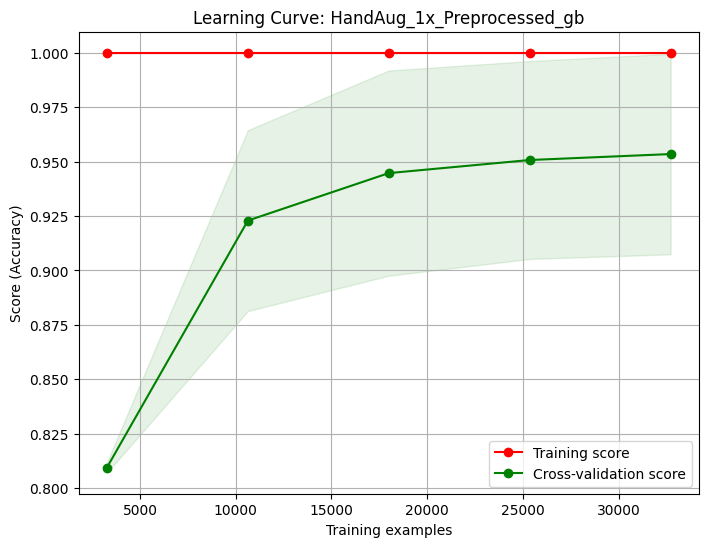

📌 Accuracy : 0.9689
📌 Precision: 0.9690
📌 Recall   : 0.9689
📌 F1 Score : 0.9689

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1022
           1       0.98      0.97      0.97      1022
           2       0.97      0.96      0.97      1022
           3       0.98      0.96      0.97      1023
           4       0.95      0.97      0.96      1023
           5       0.96      0.98      0.97      1022
           6       0.98      0.97      0.97      1023
           7       0.95      0.98      0.97      1022
           8       0.97      0.97      0.97      1022
           9       0.97      0.96      0.96      1023

    accuracy                           0.97     10224
   macro avg       0.97      0.97      0.97     10224
weighted avg       0.97      0.97      0.97     10224

🏁 [END] Factor = 1x 완료


🚀 [START] Factor = 2x

[Data Prep] Loading & Preprocessing... Augment Factor: 2x
  - Preprocessing Handmade data...
  - Preprocessing O

Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


----------
iter: 2
n_candidates: 2
n_resources: 180
Fitting 2 folds for each of 2 candidates, totalling 4 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac


⏱ Training Time (Fit Time): 1061.79 sec
🎯 Best Params: {'min_samples_leaf': 10, 'max_leaf_nodes': 31, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0, 'max_iter': 180}
  - Generating Learning Curve...


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

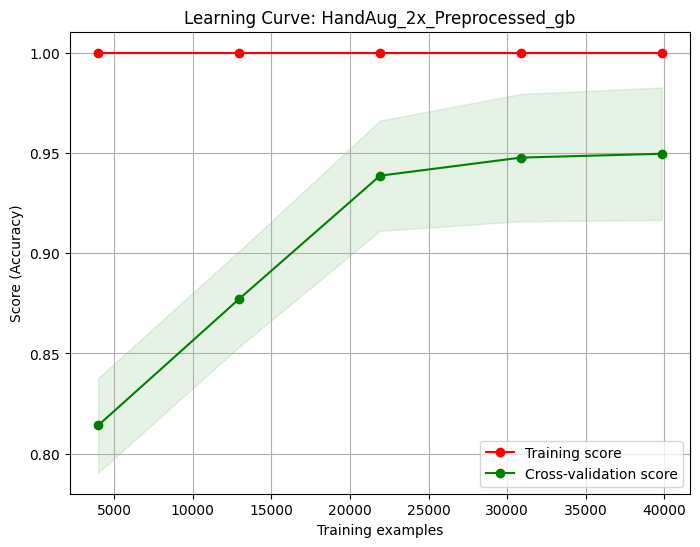

📌 Accuracy : 0.9693
📌 Precision: 0.9693
📌 Recall   : 0.9693
📌 F1 Score : 0.9693

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1022
           1       0.97      0.97      0.97      1022
           2       0.97      0.96      0.97      1022
           3       0.97      0.97      0.97      1023
           4       0.95      0.97      0.96      1023
           5       0.97      0.98      0.98      1022
           6       0.98      0.97      0.97      1023
           7       0.96      0.98      0.97      1022
           8       0.97      0.96      0.97      1022
           9       0.97      0.95      0.96      1023

    accuracy                           0.97     10224
   macro avg       0.97      0.97      0.97     10224
weighted avg       0.97      0.97      0.97     10224

🏁 [END] Factor = 2x 완료


🚀 [START] Factor = 4x

[Data Prep] Loading & Preprocessing... Augment Factor: 4x
  - Preprocessing Handmade data...
  - Preprocessing O

Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  - Augmenting Handmade Train (8896 -> 4x)...
  - Final Train Size: (67584, 784), Test Size: (10224, 784)

▶ Scenario: HandAug_4x_Preprocessed_gb (HistGradientBoosting)
  - Starting Halving Random Search...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 20
max_resources_: 200
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 20
Fitting 2 folds for each of 10 candidates, totalling 20 fits
----------
iter: 1
n_candidates: 4
n_resources: 60
Fitting 2 folds for each of 4 candidates, totalling 8 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

----------
iter: 2
n_candidates: 2
n_resources: 180
Fitting 2 folds for each of 2 candidates, totalling 4 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac


⏱ Training Time (Fit Time): 1387.04 sec
🎯 Best Params: {'min_samples_leaf': 10, 'max_leaf_nodes': 31, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0, 'max_iter': 180}
  - Generating Learning Curve...


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

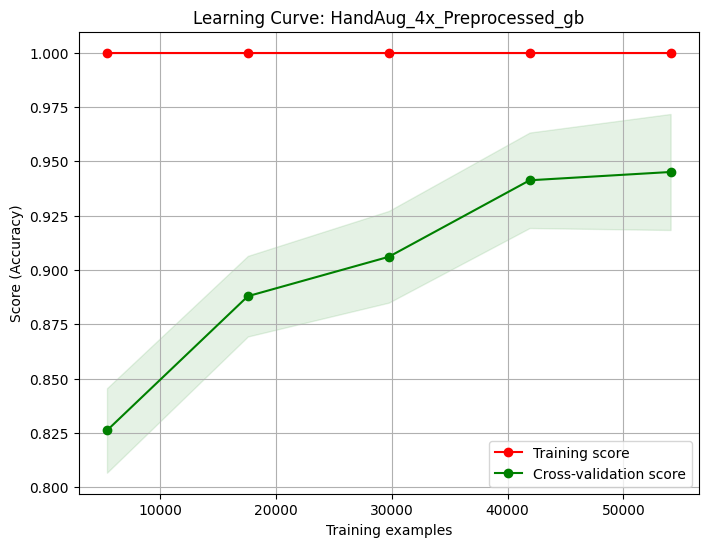

📌 Accuracy : 0.9692
📌 Precision: 0.9692
📌 Recall   : 0.9692
📌 F1 Score : 0.9692

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1022
           1       0.98      0.97      0.97      1022
           2       0.97      0.96      0.97      1022
           3       0.97      0.97      0.97      1023
           4       0.95      0.97      0.96      1023
           5       0.97      0.97      0.97      1022
           6       0.98      0.98      0.98      1023
           7       0.96      0.97      0.97      1022
           8       0.97      0.96      0.97      1022
           9       0.96      0.96      0.96      1023

    accuracy                           0.97     10224
   macro avg       0.97      0.97      0.97     10224
weighted avg       0.97      0.97      0.97     10224

🏁 [END] Factor = 4x 완료



Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138ea20>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

In [ ]:
hand_file = '../data/final/mnist_final_balanced.npz'
org_file = '../data/final/mnist_sklearn_40000.npz'


factors = [1, 2, 4]

for factor in factors:
    scenario_name = f"HandAug_{factor}x_Preprocessed_gb"
    print(f"\n🚀 [START] Factor = {factor}x")
    X_tr, X_te, y_tr, y_te = load_preprocess_and_augment(hand_file, org_file, augment_factor=factor)
    if X_tr is not None:
        run_experiment(scenario_name, X_tr, X_te, y_tr, y_te)
    print(f"🏁 [END] Factor = {factor}x 완료\n")